# ***EDA and Feature Engineering***

This exploratory data analysis would focus on addressing questions from 2 potential stakeholders: 1) Health Analytics team, and 2) Payer Strategy team. 

For the Health Analytics team, some central questions would be:
1) What does the Medicare population look like overall from 2008 to 2010?
2) What's driving utilization and cost within the Medicare population?
3) Who are the high-cost patients?

For the Payer Strategy team, some key questions would be:
1) Can we identify future high-cost beneficiaries?
2) What factors predict high cost?
3) Where should interventions be targeted and why?

In [70]:
import os
import random
import pandas as pd
import numpy as np
from src.eda import *
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# **Part 1: Data Validation**

In [47]:
patient = pd.read_csv("cleaned_data/patient_year_data_cleaned.csv")
patient.head()

,DESYNPUF_ID,BENE_ESRD_IND,BENE_COUNTY_CD,PART_A_INSUR_CVRAGE_TOT_MONS,PART_B_INSUR_CVRAGE_TOT_MONS,HMO_INSUR_CVRAGE_TOT_MONS,PART_D_INSUR_CVRAGE_TOT_MONS,year,SEX,RACE,STATE,age,age_band,IP_bill,OP_bill,Carrier_bill,num_carrier_claims,avg_carrier_claim_duration,max_carrier_claim_duration,total_carrier_claim_duration,avg_carrier_rejected_amt,max_carrier_rejected_amt,total_carrier_rejected_amt,avg_carrier_claim_rejected_rate (%),max_carrier_claim_rejected_rate (%),avg_carrier_reimb_allowed_diff,min_carrier_reimb_allowed_diff,max_carrier_reimb_allowed_diff,total_carrier_reimb_allowed_diff,max_carrier_chronic_code_counts,avg_carrier_insurance_cost,max_carrier_insurance_cost,total_carrier_insurance_cost,avg_carrier_beneficiary_cost,max_carrier_beneficiary_cost,total_carrier_beneficiary_cost,has_Additional endocrine/metabolic burden,has_COPD,has_Administrative_screening_aftercare,has_Cancer,has_Injury/Frailty Burden,has_Additional cardiovascular burden,has_Additional mental health burden,has_Additional Musculoskeletal Burden,has_Infectious disease burden,has_Stroke/TIA,has_Additional neurologic burden,has_Diabetes,has_Additional renal burden,has_Genitourinary (non-renal) burden,has_Sensory Burden,has_Additional Hematologic burden,has_Rheumatoid Arthritis/Osteoarthritis,has_Depression,has_Heart Failure,has_CKD,has_Additional GI/Hepatic burden,num_ip_claims,avg_ip_claim_duration,max_ip_claim_duration,total_ip_claim_duration,avg_ip_pmt,max_ip_pmt,total_ip_pmt,max_ip_chronic_code_counts,avg_inpatient_insurance_cost,max_inpatient_insurance_cost,total_inpatient_insurance_cost,avg_inpatient_beneficiary_cost,max_inpatient_beneficiary_cost,total_inpatient_beneficiary_cost,num_op_claims,avg_op_claim_duration,max_op_claim_duration,total_op_claim_duration,avg_op_pmt,max_op_pmt,total_op_pmt,max_op_chronic_code_counts,avg_outpatient_insurance_cost,max_outpatient_insurance_cost,total_outpatient_insurance_cost,avg_outpatient_beneficiary_cost,max_outpatient_beneficiary_cost,total_outpatient_beneficiary_cost,num_pde_claims,total_days_medsupplied,avg_days_supplied_per_pdeclaim,max_days_supplied_per_pdeclaim,total_medoop,avg_medoop_per_claim,max_medoop_per_claim,total_raw_drug_cost,avg_raw_drug_cost_per_claim,max_raw_drug_cost_per_claim,has_carrier_record,has_ip_record,has_op_record,has_pde_record,num_service_types
0,000102649ED5601B,0,290,12,12,0,12,2008,Female,White,VA,77,75-84,0.0,450.0,1030.0,16.0,0 days 01:30:00,1 days,1 days,0.000000,0.0,0.0,0.000000,0.0,22.500000,0.0,210.0,360.0,3.0,63.750000,290.0,1020.0,12.500000,50.0,200.0,1.0,1,1.0,1,1.0,1.0,1.0,1.0,1.0,1,1.0,1,1.0,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0 days 00:00:00,0 days,0 days,150.000000,320.0,450.0,1.0,120.000000,300.0,360.0,30.000000,70.0,90.0,21.0,760.0,36.190476,90.0,70.0,3.333333,10.0,500.0,23.809524,120.0,True,False,True,True,3.0
1,0002278C944E240A,1,250,12,12,0,12,2008,Female,White,NC,72,65-74,0.0,4120.0,6230.0,42.0,0 days 17:08:34.285714285,9 days,30 days,2.142857,50.0,90.0,4.878049,100.0,25.000000,0.0,470.0,1050.0,4.0,130.714280,750.0,5490.0,32.142857,310.0,1350.0,1.0,1,1.0,1,1.0,1.0,1.0,1.0,1.0,0,1.0,1,1.0,1.0,1.0,1.0,1,1,1,1,1.0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.0,1 days 03:41:32.307692307,13 days,15 days,316.923077,1050.0,4120.0,7.0,199.230769,800.0,2590.0,117.692308,1000.0,1530.0,47.0,1210.0,25.744681,90.0,440.0,9.361702,170.0,3580.0,76.170213,570.0,True,False,True,True,3.0
2,000330E625C93700,0,420,12,12,0,0,2008,Female,White,AR,75,75-84,0.0,0.0,420.0,4.0,0 days 00:00:00,0 days,0 days,0.000000,0.0,0.0,0.000000,0.0,30.000000,0.0,60.0,120.0,1.0,67.500000,90.0,270.0,37.500000,70.0,150.0,0.0,0,0.0,0,0.0,1.0,0.0,0.0,1.0,0,0.0,0,0.0,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,True,False,False,False,1.0
3,000374D5E110EDA6,0,90,12,12,0,12,2008,Female,White,CA,72,65-74,0.0,90.

In [48]:
patient.columns

Index(['DESYNPUF_ID', 'BENE_ESRD_IND', 'BENE_COUNTY_CD',
       'PART_A_INSUR_CVRAGE_TOT_MONS', 'PART_B_INSUR_CVRAGE_TOT_MONS',
       'HMO_INSUR_CVRAGE_TOT_MONS', 'PART_D_INSUR_CVRAGE_TOT_MONS', 'year',
       'SEX', 'RACE', 'STATE', 'age', 'age_band', 'IP_bill', 'OP_bill',
       'Carrier_bill', 'num_carrier_claims', 'avg_carrier_claim_duration',
       'max_carrier_claim_duration', 'total_carrier_claim_duration',
       'avg_carrier_rejected_amt', 'max_carrier_rejected_amt',
       'total_carrier_rejected_amt', 'avg_carrier_claim_rejected_rate (%)',
       'max_carrier_claim_rejected_rate (%)', 'avg_carrier_reimb_allowed_diff',
       'min_carrier_reimb_allowed_diff', 'max_carrier_reimb_allowed_diff',
       'total_carrier_reimb_allowed_diff', 'max_carrier_chronic_code_counts',
       'avg_carrier_insurance_cost', 'max_carrier_insurance_cost',
       'total_carrier_insurance_cost', 'avg_carrier_beneficiary_cost',
       'max_carrier_beneficiary_cost', 'total_carrier_beneficiary_cost

In [49]:
cost_cols = ['IP_bill', 'OP_bill','Carrier_bill', 'total_carrier_rejected_amt', 'total_ip_pmt', 'total_op_pmt', 'total_medoop', 'total_raw_drug_cost']
patient[cost_cols].head()

,IP_bill,OP_bill,Carrier_bill,total_carrier_rejected_amt,total_ip_pmt,total_op_pmt,total_medoop,total_raw_drug_cost
0,0.0,450.0,1030.0,0.0,0.0,450.0,70.0,500.0
1,0.0,4120.0,6230.0,90.0,0.0,4120.0,440.0,3580.0
2,0.0,0.0,420.0,0.0,0.0,0.0,0.0,0.0
3,0.0,90.0,1450.0,0.0,0.0,90.0,270.0,2960.0
4,0.0,4110.0,4550.0,80.0,0.0,4110.0,490.0,3060.0


### Inpatient Bills ###

In [50]:
cost_table = patient[cost_cols]
cost_table["ip_bill_diff"] = cost_table["IP_bill"] - cost_table["total_ip_pmt"]
(cost_table["ip_bill_diff"] == 0).mean()

/var/folders/hy/wt2n1k0x6fbbw2fdl3gw2jp00000gn/T/ipykernel_34242/1213952793.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cost_table["ip_bill_diff"] = cost_table["IP_bill"] - cost_table["total_ip_pmt"]


np.float64(0.946885125671037)

In [51]:
cost_table["ip_bill_diff"].describe(percentiles=[0.5,0.75,0.9,0.95,0.99])

count    332694.000000
mean         38.445599
std        1397.908366
min      -86068.000000
50%           0.000000
75%           0.000000
90%           0.000000
95%          10.000000
99%        1024.000000
max       86068.000000
Name: ip_bill_diff, dtype: float64

In [52]:
patient["ip_bill_diff"] = patient["IP_bill"] - patient["total_ip_pmt"]
indx = patient["ip_bill_diff"].abs().idxmax()
patient.loc[indx, ["DESYNPUF_ID", "year", "IP_bill", "total_ip_pmt", "ip_bill_diff"]]

DESYNPUF_ID     38462DEE99A7FDEE
year                        2008
IP_bill                      0.0
total_ip_pmt             86068.0
ip_bill_diff            -86068.0
Name: 24474, dtype: object

In [53]:
inpatient = pd.read_csv("data/inpatient/DE1_0_2008_to_2010_Inpatient_Claims_Sample_9.csv")
inpatient.columns
inpatient[inpatient["DESYNPUF_ID"] == "38462DEE99A7FDEE"]
#[["CLM_ID", "CLM_FROM_DT", "CLM_THRU_DT", "CLM_PMT_AMT", "NCH_PRMRY_PYR_CLM_PD_AMT", 'NCH_BENE_IP_DDCTBL_AMT',
#       "NCH_BENE_PTA_COINSRNC_LBLTY_AM", 'NCH_BENE_BLOOD_DDCTBL_LBLTY_AM']]  

,DESYNPUF_ID,CLM_ID,SEGMENT,CLM_FROM_DT,CLM_THRU_DT,PRVDR_NUM,CLM_PMT_AMT,NCH_PRMRY_PYR_CLM_PD_AMT,AT_PHYSN_NPI,OP_PHYSN_NPI,OT_PHYSN_NPI,CLM_ADMSN_DT,ADMTNG_ICD9_DGNS_CD,CLM_PASS_THRU_PER_DIEM_AMT,NCH_BENE_IP_DDCTBL_AMT,NCH_BENE_PTA_COINSRNC_LBLTY_AM,NCH_BENE_BLOOD_DDCTBL_LBLTY_AM,CLM_UTLZTN_DAY_CNT,NCH_BENE_DSCHRG_DT,CLM_DRG_CD,ICD9_DGNS_CD_1,ICD9_DGNS_CD_2,ICD9_DGNS_CD_3,ICD9_DGNS_CD_4,ICD9_DGNS_CD_5,ICD9_DGNS_CD_6,ICD9_DGNS_CD_7,ICD9_DGNS_CD_8,ICD9_DGNS_CD_9,ICD9_DGNS_CD_10,ICD9_PRCDR_CD_1,ICD9_PRCDR_CD_2,ICD9_PRCDR_CD_3,ICD9_PRCDR_CD_4,ICD9_PRCDR_CD_5,ICD9_PRCDR_CD_6,HCPCS_CD_1,HCPCS_CD_2,HCPCS_CD_3,HCPCS_CD_4,HCPCS_CD_5,HCPCS_CD_6,HCPCS_CD_7,HCPCS_CD_8,HCPCS_CD_9,HCPCS_CD_10,HCPCS_CD_11,HCPCS_CD_12,HCPCS_CD_13,HCPCS_CD_14,HCPCS_CD_15,HCPCS_CD_16,HCPCS_CD_17,HCPCS_CD_18,HCPCS_CD_19,HCPCS_CD_20,HCPCS_CD_21,HCPCS_CD_22,HCPCS_CD_23,HCPCS_CD_24,HCPCS_CD_25,HCPCS_CD_26,HCPCS_CD_27,HCPCS_CD_28,HCPCS_CD_29,HCPCS_CD_30,HCPCS_CD_31,HCPCS_CD_32,HCPCS_CD_33,HCPCS_CD_34,HCPCS_CD_35,HCPCS_CD_36,HCPCS_CD_37,HCPCS_CD_38,HCPCS_CD_39,HCPCS_CD_40,HCPCS_CD_41,HCPCS_CD_42,HCPCS_CD_43,HCPCS_CD_44,HCPCS_CD_45
14823,38462DEE99A7FDEE,992291161641456,1,20081230.0,20090106.0,1030RD,17000.0,68000.0,3.013810e+09,3.846563e+09,3.013810e+09,20081230,71945,0.0,1068.0,0.0,0.0,7.0,20090106,564,71536,42731,5070,40390,5859,E8788,5185,42830,7845,NaN,8152.0,34831,51884,2724,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [54]:
inpatient_cleaned = pd.read_csv("cleaned_data/ip_patient_year.csv")
inpatient_cleaned.columns

Index(['DESYNPUF_ID', 'claim_year', 'num_ip_claims', 'avg_claim_duration',
       'max_claim_duration', 'total_claim_duration', 'avg_ip_pmt',
       'max_ip_pmt', 'total_ip_pmt', 'max_chronic_code_counts',
       'avg_inpatient_insurance_cost', 'max_inpatient_insurance_cost',
       'total_inpatient_insurance_cost', 'avg_inpatient_beneficiary_cost',
       'max_inpatient_beneficiary_cost', 'total_inpatient_beneficiary_cost',
       'has_Infectious disease burden', 'has_Injury/Frailty Burden', 'has_CKD',
       'has_Additional endocrine/metabolic burden',
       'has_Additional renal burden', 'has_Additional cardiovascular burden',
       'has_Additional neurologic burden', 'has_Additional GI/Hepatic burden',
       'has_Additional Hematologic burden', 'has_Sensory Burden', 'has_Cancer',
       'has_Additional mental health burden', 'has_Stroke/TIA',
       'has_Depression', 'has_Diabetes',
       'has_Administrative_screening_aftercare',
       'has_Additional Musculoskeletal Burden', 

In [55]:
inpatient_cleaned[
    inpatient_cleaned["DESYNPUF_ID"]=="38462DEE99A7FDEE"
][
    ["DESYNPUF_ID","claim_year","total_ip_pmt"]
]

,DESYNPUF_ID,claim_year,total_ip_pmt
10486,38462DEE99A7FDEE,2008,86068.0


Inpatient payment totals were compared between claim-level aggregations and beneficiary-level summary fields. While most patient-year observations reconciled, a subset showed discrepancies. Investigation confirmed that these differences were not caused by missing value propagation or aggregation errors. Given the synthetic nature of DE-SynPUF data and limited availability of payment-related variables, discrepancies likely reflect differences in field definitions and omitted payment components.


### Outpatient bills ###

In [56]:
patient["op_bill_diff"] = patient["OP_bill"] - patient["total_op_pmt"]
patient["op_bill_diff"].describe(percentiles=[0.5,0.75,0.9,0.95,0.99])

count    332694.000000
mean          1.101553
std         201.846549
min      -12200.000000
50%           0.000000
75%           0.000000
90%           0.000000
95%           0.000000
99%           0.000000
max       12200.000000
Name: op_bill_diff, dtype: float64

In [57]:
(patient["op_bill_diff"] == 0).mean()

np.float64(0.986492091832134)

In [58]:
indx = patient["op_bill_diff"].abs().idxmax()
patient.loc[indx, ["DESYNPUF_ID", "year", "OP_bill", "total_op_pmt", "op_bill_diff"]]

DESYNPUF_ID     2C2F1FE5B47013AB
year                        2008
OP_bill                  42390.0
total_op_pmt             54590.0
op_bill_diff            -12200.0
Name: 19049, dtype: object

In [59]:
outpatient_cleaned = pd.read_csv("cleaned_data/op_patient_year.csv")
outpatient_cleaned[
    outpatient_cleaned["DESYNPUF_ID"]=="2C2F1FE5B47013AB"
][
    ["DESYNPUF_ID","claim_year","total_op_pmt"]
]


,DESYNPUF_ID,claim_year,total_op_pmt
32233,2C2F1FE5B47013AB,2008,54590.0
32234,2C2F1FE5B47013AB,2009,29180.0


In [60]:
outpatient = pd.read_csv("data/outpatient/DE1_0_2008_to_2010_Outpatient_Claims_Sample_9.csv")
outpatient[outpatient["DESYNPUF_ID"] == "2C2F1FE5B47013AB"][["CLM_FROM_DT", "CLM_PMT_AMT", "NCH_PRMRY_PYR_CLM_PD_AMT", "NCH_BENE_BLOOD_DDCTBL_LBLTY_AM", "NCH_BENE_PTB_DDCTBL_AMT", "NCH_BENE_PTB_COINSRNC_AMT"]]

/var/folders/hy/wt2n1k0x6fbbw2fdl3gw2jp00000gn/T/ipykernel_34242/3008638576.py:1: DtypeWarning: Columns (21,23,24,25,26,27) have mixed types. Specify dtype option on import or set low_memory=False.
  outpatient = pd.read_csv("data/outpatient/DE1_0_2008_to_2010_Outpatient_Claims_Sample_9.csv")


,CLM_FROM_DT,CLM_PMT_AMT,NCH_PRMRY_PYR_CLM_PD_AMT,NCH_BENE_BLOOD_DDCTBL_LBLTY_AM,NCH_BENE_PTB_DDCTBL_AMT,NCH_BENE_PTB_COINSRNC_AMT
137032,NaN,900.0,0.0,0.0,0.0,500.0
137033,NaN,2300.0,0.0,0.0,0.0,600.0
137034,NaN,2100.0,0.0,0.0,0.0,900.0
137035,NaN,1600.0,0.0,0.0,0.0,600.0
137036,NaN,2300.0,0.0,0.0,0.0,70.0
137037,NaN,3300.0,0.0,0.0,0.0,500.0
137038,NaN,3300.0,0.0,0.0,0.0,400.0
137039,NaN,1300.0,0.0,0.0,0.0,500.0
137040,NaN,1700.0,0.0,0.0,0.0,400.0
137041,NaN,1800.0,0.0,0.0,0.0,0.0


In [61]:
op_check = patient[patient["op_bill_diff"] != 0]
op_check.sort_values("op_bill_diff", key=abs, ascending=False).head(10)

,DESYNPUF_ID,BENE_ESRD_IND,BENE_COUNTY_CD,PART_A_INSUR_CVRAGE_TOT_MONS,PART_B_INSUR_CVRAGE_TOT_MONS,HMO_INSUR_CVRAGE_TOT_MONS,PART_D_INSUR_CVRAGE_TOT_MONS,year,SEX,RACE,STATE,age,age_band,IP_bill,OP_bill,Carrier_bill,num_carrier_claims,avg_carrier_claim_duration,max_carrier_claim_duration,total_carrier_claim_duration,avg_carrier_rejected_amt,max_carrier_rejected_amt,total_carrier_rejected_amt,avg_carrier_claim_rejected_rate (%),max_carrier_claim_rejected_rate (%),avg_carrier_reimb_allowed_diff,min_carrier_reimb_allowed_diff,max_carrier_reimb_allowed_diff,total_carrier_reimb_allowed_diff,max_carrier_chronic_code_counts,avg_carrier_insurance_cost,max_carrier_insurance_cost,total_carrier_insurance_cost,avg_carrier_beneficiary_cost,max_carrier_beneficiary_cost,total_carrier_beneficiary_cost,has_Additional endocrine/metabolic burden,has_COPD,has_Administrative_screening_aftercare,has_Cancer,has_Injury/Frailty Burden,has_Additional cardiovascular burden,has_Additional mental health burden,has_Additional Musculoskeletal Burden,has_Infectious disease burden,has_Stroke/TIA,has_Additional neurologic burden,has_Diabetes,has_Additional renal burden,has_Genitourinary (non-renal) burden,has_Sensory Burden,has_Additional Hematologic burden,has_Rheumatoid Arthritis/Osteoarthritis,has_Depression,has_Heart Failure,has_CKD,has_Additional GI/Hepatic burden,num_ip_claims,avg_ip_claim_duration,max_ip_claim_duration,total_ip_claim_duration,avg_ip_pmt,max_ip_pmt,total_ip_pmt,max_ip_chronic_code_counts,avg_inpatient_insurance_cost,max_inpatient_insurance_cost,total_inpatient_insurance_cost,avg_inpatient_beneficiary_cost,max_inpatient_beneficiary_cost,total_inpatient_beneficiary_cost,num_op_claims,avg_op_claim_duration,max_op_claim_duration,total_op_claim_duration,avg_op_pmt,max_op_pmt,total_op_pmt,max_op_chronic_code_counts,avg_outpatient_insurance_cost,max_outpatient_insurance_cost,total_outpatient_insurance_cost,avg_outpatient_beneficiary_cost,max_outpatient_beneficiary_cost,total_outpatient_beneficiary_cost,num_pde_claims,total_days_medsupplied,avg_days_supplied_per_pdeclaim,max_days_supplied_per_pdeclaim,total_medoop,avg_medoop_per_claim,max_medoop_per_claim,total_raw_drug_cost,avg_raw_drug_cost_per_claim,max_raw_drug_cost_per_claim,has_carrier_record,has_ip_record,has_op_record,has_pde_record,num_service_types,ip_bill_diff,op_bill_diff
129947,2C2F1FE5B47013AB,1,210,12,12,12,12,2009,Male,Others,WA,31,<65,7068.0,41380.0,7980.0,49.0,0 days 09:47:45.306122448,9 days,20 days,0.000000,0.0,0.0,0.000000,0.000000,11.224490,0.0,170.0,550.0,4.0,135.714280,1340.0,6650.0,34.693878,280.0,1700.0,1.0,1,1.0,1,1.0,1.0,1.0,1.0,1.0,1,1.0,1,1.0,0.0,1.0,1.0,1,1,1,1,1.0,1.0,1 days 00:00:00,1 days,1 days,7068.0,7068.0,7068.0,6.0,6000.0,6000.0,6000.0,1068.0,1068.0,1068.0,16.0,13 days 00:00:00,20 days,208 days,1823.750000,4100.0,29180.0,5.0,1386.250000,3300.0,22180.0,437.500000,1000.0,7000.0,6.0,240.0,40.000000,90.0,70.0,11.666667,30.0,450.0,75.000000,200.0,True,True,True,True,4.0,0.0,12200.0
19049,2C2F1FE5B47013AB,1,210,12,12,0,0,2008,Male,Others,WA,30,<65,0.0,42390.0,9560.0,60.0,0 days 11:12:00,9 days,28 days,0.000000,0.0,0.0,0.000000,0.000000,26.000000,0.0,500.0,1560.0,6.0,138.000000,610.0,8280.0,30.166667,220.0,1810.0,1.0,1,1.0,1,1.0,1.0,1.0,1.0,1.0,1,1.0,1,1.0,1.0,1.0,1.0,1,1,1,1,1.0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.0,10 days 00:00:00,20 days,230 days,2373.478261,12300.0,54590.0,7.0,1988.260870,11700.0,45730.0,385.217391,1000.0,8860.0,1.0,20.0,20.000000,20.0,40.0,40.000000,40.0,160.0,160.000000,160.0,True,False,True,True,3.0,0.0,-12200.0
182835,A5C97A2C67A8052A,1,400,12,12,0,12,2009,Female,White,CA,81,75-84,15136.0,35910.0,10130.0,69.0,0 days 08:41:44.347826086,9 days,25 days,1.739130,120.0,120.0,0.344432,23.076923,25.217391,0.0,260.0,1740.0,5.0,125.942030,1040.0,8690.0,28.985507,280.0,2000.0,1.0,1,1.0,1,1.0,1.0,1.0,1.0,1.0,0,1.0,1,1.0,1.0,1.0,1.0,1,1,1,1,1.0,2.0,4 days 00:00:00,6 days,8 days,7568.0,8068.0,15136.0,6.0,6500.0,7000.0,13000.0,1068.0,

Outpatient payment reconciliation showed 98.65% exact agreement between claim-level aggregation and beneficiary-level payment summaries. The remaining discrepancies were primarily isolated to a small number of beneficiaries and included offsetting year-to-year differences (e.g., -$12,200 in one year and +$12,200 in the following year), suggesting payment adjustments or timing differences rather than aggregation errors.

### Carrier Bills ###

In [62]:
patient["total_carrier_rejected_amt"].describe(percentiles=[.5,.75,.9,.95,.99])

count    332694.000000
mean         18.382057
std          60.941237
min           0.000000
50%           0.000000
75%           0.000000
90%          50.000000
95%         100.000000
99%         320.000000
max        1500.000000
Name: total_carrier_rejected_amt, dtype: float64

<Axes: >

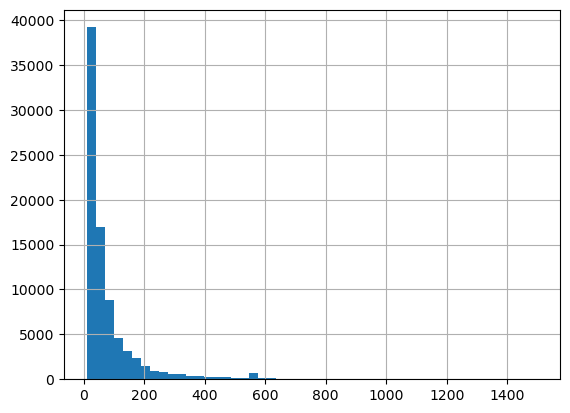

In [63]:
carrier_positive = patient[
    patient["total_carrier_rejected_amt"] > 0
]

carrier_positive["total_carrier_rejected_amt"].hist(
    bins=50
)

In [64]:
# quantile-based bins to help visualize distributions
pd.cut(
    patient["total_carrier_rejected_amt"],
    bins=[0,20,50,100,250,500,1000,1500]
).value_counts()

total_carrier_rejected_amt
(0, 20]         29015
(20, 50]        23023
(50, 100]       14879
(100, 250]      10862
(250, 500]       3190
(500, 1000]      1386
(1000, 1500]       27
Name: count, dtype: int64

Due to the higher variability of carrier claim structures, attempts to aggregate additional payment components resulted in alignment challenges. The rejected amount variable was retained because it provides a consistent indicator of claim processing/payment rejection behavior.

Rejected carrier amounts were concentrated among low-value events. Approximately 90% of beneficiary-years had rejected amounts below 50, while a small tail of cases exceeded 320 and reached up to 1,500.

# **PDE Bills**

In [65]:
patient[["total_medoop", "total_raw_drug_cost"]].corr()

,total_medoop,total_raw_drug_cost
total_medoop,1.000000,0.878005
total_raw_drug_cost,0.878005,1.000000


In [66]:
patient[["total_medoop", "total_raw_drug_cost"]].describe()

,total_medoop,total_raw_drug_cost
count,332694.000000,332694.000000
mean,167.408760,997.191413
std,240.578056,1481.971670
min,0.000000,0.000000
25%,0.000000,0.000000
50%,50.000000,320.000000
75%,260.000000,1420.000000
max,2490.000000,15690.000000


In [67]:
(patient["total_medoop"] > patient["total_raw_drug_cost"]).mean()

np.float64(0.0073430840351794745)

In [68]:
patient.loc[
    patient["total_medoop"] > patient["total_raw_drug_cost"],
    ["total_medoop","total_raw_drug_cost"]
].describe()

,total_medoop,total_raw_drug_cost
count,2443.000000,2443.000000
mean,69.938600,44.126074
std,69.887856,56.052980
min,10.000000,0.000000
25%,20.000000,10.000000
50%,40.000000,20.000000
75%,110.000000,70.000000
max,590.000000,370.000000


Total Medicare out-of-pocket drug payments and raw drug costs showed strong positive correlation (r=0.878), suggesting that both variables capture related medication spending patterns while representing distinct financial perspectives. A small subset of observations (0.73%) showed out-of-pocket payments exceeding raw drug costs, which may reflect differences in payment definitions, aggregation processes, or synthetic data generation constraints rather than systematic data errors.

# **Part 2: Define Outcome**

## Cost Variable Definition

To identify high-cost patients, healthcare costs were calculated using patient-year claim-level aggregations. This approach was selected to maintain consistency with downstream analyses of healthcare utilization intensity and chronic disease burden while preserving full traceability of cost derivation throughout the analytical pipeline.

Rather than treating all payment-related variables as a single undifferentiated cost measure, financial burden was decomposed into three components:

* **Payer Care Cost**: healthcare expenditures borne by Medicare, primary payers, and other insurance entities.
* **Out-of-Pocket Care Cost**: healthcare expenditures borne directly by beneficiaries and their families.
* **Claim Processing Burden**: rejected carrier claim amounts representing reimbursement and claims-processing friction.

A combined **Total Financial Impact** measure was then constructed to capture the overall financial burden associated with each beneficiary-year.

Claim-derived payment estimates were validated against beneficiary-level payment summaries, demonstrating greater than 94% alignment. Remaining discrepancies were concentrated among a small subset of observations and are likely attributable to differences in payment field definitions, omitted payment components, aggregation differences, or synthetic data generation constraints designed to preserve privacy while maintaining analytical utility within the DE-SynPUF dataset. Given the strong overall agreement and greater interpretability of claim-level calculations, claim-derived measures were retained for downstream analyses.

### Cost Calculation

* **Payer Care Cost** = Carrier Insurance Cost + Inpatient Insurance Cost + Outpatient Insurance Cost + Raw Drug Cost

* **Out-of-Pocket Care Cost** = Carrier Beneficiary Cost + Inpatient Beneficiary Cost + Outpatient Beneficiary Cost + Drug OOP Cost

* **Claim Processing Burden** = Total Carrier Rejected Amount

* **Total Financial Impact** = Payer Care Cost + Out-of-Pocket Care Cost 

### Validation Against Beneficiary-Level Payments

| Metric           | Result                                                                 |
| ---------------- | ---------------------------------------------------------------------- |
| Alignment        | >94%                                                                   |
| Validation Grain | Patient-year                                                           |
| Comparison       | Claim-derived financial impact vs. beneficiary-level payment summaries |
| Decision         | Retain claim-derived measures for downstream analysis                  |

### Limitations

* DE-SynPUF is a synthetic dataset and may not preserve all payment relationships at the individual beneficiary level.
* Certain payment components may be omitted, transformed, or aggregated differently to protect privacy.
* Small discrepancies between claim-derived and beneficiary-level payments likely reflect differences in payment definitions and reporting structures.
* Rejected carrier claim amounts were retained as a measure of administrative and reimbursement burden and hence interpreted separately from reimbursed healthcare expenditures.


In [72]:
patient.head()

,DESYNPUF_ID,BENE_ESRD_IND,BENE_COUNTY_CD,PART_A_INSUR_CVRAGE_TOT_MONS,PART_B_INSUR_CVRAGE_TOT_MONS,HMO_INSUR_CVRAGE_TOT_MONS,PART_D_INSUR_CVRAGE_TOT_MONS,year,SEX,RACE,STATE,age,age_band,IP_bill,OP_bill,Carrier_bill,num_carrier_claims,avg_carrier_claim_duration,max_carrier_claim_duration,total_carrier_claim_duration,avg_carrier_rejected_amt,max_carrier_rejected_amt,total_carrier_rejected_amt,avg_carrier_claim_rejected_rate (%),max_carrier_claim_rejected_rate (%),avg_carrier_reimb_allowed_diff,min_carrier_reimb_allowed_diff,max_carrier_reimb_allowed_diff,total_carrier_reimb_allowed_diff,max_carrier_chronic_code_counts,avg_carrier_insurance_cost,max_carrier_insurance_cost,total_carrier_insurance_cost,avg_carrier_beneficiary_cost,max_carrier_beneficiary_cost,total_carrier_beneficiary_cost,has_Additional endocrine/metabolic burden,has_COPD,has_Administrative_screening_aftercare,has_Cancer,has_Injury/Frailty Burden,has_Additional cardiovascular burden,has_Additional mental health burden,has_Additional Musculoskeletal Burden,has_Infectious disease burden,has_Stroke/TIA,has_Additional neurologic burden,has_Diabetes,has_Additional renal burden,has_Genitourinary (non-renal) burden,has_Sensory Burden,has_Additional Hematologic burden,has_Rheumatoid Arthritis/Osteoarthritis,has_Depression,has_Heart Failure,has_CKD,has_Additional GI/Hepatic burden,num_ip_claims,avg_ip_claim_duration,max_ip_claim_duration,total_ip_claim_duration,avg_ip_pmt,max_ip_pmt,total_ip_pmt,max_ip_chronic_code_counts,avg_inpatient_insurance_cost,max_inpatient_insurance_cost,total_inpatient_insurance_cost,avg_inpatient_beneficiary_cost,max_inpatient_beneficiary_cost,total_inpatient_beneficiary_cost,num_op_claims,avg_op_claim_duration,max_op_claim_duration,total_op_claim_duration,avg_op_pmt,max_op_pmt,total_op_pmt,max_op_chronic_code_counts,avg_outpatient_insurance_cost,max_outpatient_insurance_cost,total_outpatient_insurance_cost,avg_outpatient_beneficiary_cost,max_outpatient_beneficiary_cost,total_outpatient_beneficiary_cost,num_pde_claims,total_days_medsupplied,avg_days_supplied_per_pdeclaim,max_days_supplied_per_pdeclaim,total_medoop,avg_medoop_per_claim,max_medoop_per_claim,total_raw_drug_cost,avg_raw_drug_cost_per_claim,max_raw_drug_cost_per_claim,has_carrier_record,has_ip_record,has_op_record,has_pde_record,num_service_types,ip_bill_diff,op_bill_diff
0,000102649ED5601B,0,290,12,12,0,12,2008,Female,White,VA,77,75-84,0.0,450.0,1030.0,16.0,0 days 01:30:00,1 days,1 days,0.000000,0.0,0.0,0.000000,0.0,22.500000,0.0,210.0,360.0,3.0,63.750000,290.0,1020.0,12.500000,50.0,200.0,1.0,1,1.0,1,1.0,1.0,1.0,1.0,1.0,1,1.0,1,1.0,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0 days 00:00:00,0 days,0 days,150.000000,320.0,450.0,1.0,120.000000,300.0,360.0,30.000000,70.0,90.0,21.0,760.0,36.190476,90.0,70.0,3.333333,10.0,500.0,23.809524,120.0,True,False,True,True,3.0,0.0,0.0
1,0002278C944E240A,1,250,12,12,0,12,2008,Female,White,NC,72,65-74,0.0,4120.0,6230.0,42.0,0 days 17:08:34.285714285,9 days,30 days,2.142857,50.0,90.0,4.878049,100.0,25.000000,0.0,470.0,1050.0,4.0,130.714280,750.0,5490.0,32.142857,310.0,1350.0,1.0,1,1.0,1,1.0,1.0,1.0,1.0,1.0,0,1.0,1,1.0,1.0,1.0,1.0,1,1,1,1,1.0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.0,1 days 03:41:32.307692307,13 days,15 days,316.923077,1050.0,4120.0,7.0,199.230769,800.0,2590.0,117.692308,1000.0,1530.0,47.0,1210.0,25.744681,90.0,440.0,9.361702,170.0,3580.0,76.170213,570.0,True,False,True,True,3.0,0.0,0.0
2,000330E625C93700,0,420,12,12,0,0,2008,Female,White,AR,75,75-84,0.0,0.0,420.0,4.0,0 days 00:00:00,0 days,0 days,0.000000,0.0,0.0,0.000000,0.0,30.000000,0.0,60.0,120.0,1.0,67.500000,90.0,270.0,37.500000,70.0,150.0,0.0,0,0.0,0,0.0,1.0,0.0,0.0,1.0,0,0.0,0,0.0,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,True,False,False,False,1.0,0.0,0.0
3,000374D5E110EDA6,0,9

In [86]:
cost_cols = [
    "total_carrier_insurance_cost",
    "total_inpatient_insurance_cost",
    "total_outpatient_insurance_cost",
    "total_raw_drug_cost",
    "total_carrier_beneficiary_cost",
    "total_inpatient_beneficiary_cost",
    "total_outpatient_beneficiary_cost",
    "total_medoop"
]

for col in cost_cols:
    print(col, (patient[col] < 0).sum())

total_carrier_insurance_cost 0
total_inpatient_insurance_cost 30
total_outpatient_insurance_cost 168
total_raw_drug_cost 0
total_carrier_beneficiary_cost 0
total_inpatient_beneficiary_cost 0
total_outpatient_beneficiary_cost 0
total_medoop 0


Negative institutional payment values were rare (<0.1%) and treated as payment adjustments. For expenditure estimation, negative values were set to zero to avoid reducing observed healthcare spending due to administrative reversals.

In [82]:
patient["total_inpatient_insurance_cost_adj"] = patient["total_inpatient_insurance_cost"].clip(lower=0)
patient["total_outpatient_insurance_cost_adj"] = patient["total_outpatient_insurance_cost"].clip(lower=0)
system_cost_components = ["total_carrier_insurance_cost", "total_inpatient_insurance_cost_adj", "total_outpatient_insurance_cost_adj", "total_raw_drug_cost"]
beneficiary_cost_components = ["total_carrier_beneficiary_cost", "total_inpatient_beneficiary_cost", "total_outpatient_beneficiary_cost", "total_medoop"]

patient["claim_processing_burden"] = patient["total_carrier_rejected_amt"] 
patient["payer_care_cost"] = patient[system_cost_components].sum(axis=1)
patient["out_of_pocket_care_cost"] = patient[beneficiary_cost_components].sum(axis=1)
patient["total_financial_impact"] = patient["payer_care_cost"] + patient["out_of_pocket_care_cost"] 
patient.head()

,DESYNPUF_ID,BENE_ESRD_IND,BENE_COUNTY_CD,PART_A_INSUR_CVRAGE_TOT_MONS,PART_B_INSUR_CVRAGE_TOT_MONS,HMO_INSUR_CVRAGE_TOT_MONS,PART_D_INSUR_CVRAGE_TOT_MONS,year,SEX,RACE,STATE,age,age_band,IP_bill,OP_bill,Carrier_bill,num_carrier_claims,avg_carrier_claim_duration,max_carrier_claim_duration,total_carrier_claim_duration,avg_carrier_rejected_amt,max_carrier_rejected_amt,total_carrier_rejected_amt,avg_carrier_claim_rejected_rate (%),max_carrier_claim_rejected_rate (%),avg_carrier_reimb_allowed_diff,min_carrier_reimb_allowed_diff,max_carrier_reimb_allowed_diff,total_carrier_reimb_allowed_diff,max_carrier_chronic_code_counts,avg_carrier_insurance_cost,max_carrier_insurance_cost,total_carrier_insurance_cost,avg_carrier_beneficiary_cost,max_carrier_beneficiary_cost,total_carrier_beneficiary_cost,has_Additional endocrine/metabolic burden,has_COPD,has_Administrative_screening_aftercare,has_Cancer,has_Injury/Frailty Burden,has_Additional cardiovascular burden,has_Additional mental health burden,has_Additional Musculoskeletal Burden,has_Infectious disease burden,has_Stroke/TIA,has_Additional neurologic burden,has_Diabetes,has_Additional renal burden,has_Genitourinary (non-renal) burden,has_Sensory Burden,has_Additional Hematologic burden,has_Rheumatoid Arthritis/Osteoarthritis,has_Depression,has_Heart Failure,has_CKD,has_Additional GI/Hepatic burden,num_ip_claims,avg_ip_claim_duration,max_ip_claim_duration,total_ip_claim_duration,avg_ip_pmt,max_ip_pmt,total_ip_pmt,max_ip_chronic_code_counts,avg_inpatient_insurance_cost,max_inpatient_insurance_cost,total_inpatient_insurance_cost,avg_inpatient_beneficiary_cost,max_inpatient_beneficiary_cost,total_inpatient_beneficiary_cost,num_op_claims,avg_op_claim_duration,max_op_claim_duration,total_op_claim_duration,avg_op_pmt,max_op_pmt,total_op_pmt,max_op_chronic_code_counts,avg_outpatient_insurance_cost,max_outpatient_insurance_cost,total_outpatient_insurance_cost,avg_outpatient_beneficiary_cost,max_outpatient_beneficiary_cost,total_outpatient_beneficiary_cost,num_pde_claims,total_days_medsupplied,avg_days_supplied_per_pdeclaim,max_days_supplied_per_pdeclaim,total_medoop,avg_medoop_per_claim,max_medoop_per_claim,total_raw_drug_cost,avg_raw_drug_cost_per_claim,max_raw_drug_cost_per_claim,has_carrier_record,has_ip_record,has_op_record,has_pde_record,num_service_types,ip_bill_diff,op_bill_diff,claim_processing_burden,payer_care_cost,out_of_pocket_care_cost,total_financial_impact,total_inpatient_insurance_cost_adj,total_outpatient_insurance_cost_adj
0,000102649ED5601B,0,290,12,12,0,12,2008,Female,White,VA,77,75-84,0.0,450.0,1030.0,16.0,0 days 01:30:00,1 days,1 days,0.000000,0.0,0.0,0.000000,0.0,22.500000,0.0,210.0,360.0,3.0,63.750000,290.0,1020.0,12.500000,50.0,200.0,1.0,1,1.0,1,1.0,1.0,1.0,1.0,1.0,1,1.0,1,1.0,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0 days 00:00:00,0 days,0 days,150.000000,320.0,450.0,1.0,120.000000,300.0,360.0,30.000000,70.0,90.0,21.0,760.0,36.190476,90.0,70.0,3.333333,10.0,500.0,23.809524,120.0,True,False,True,True,3.0,0.0,0.0,0.0,1880.0,360.0,2240.0,0.0,360.0
1,0002278C944E240A,1,250,12,12,0,12,2008,Female,White,NC,72,65-74,0.0,4120.0,6230.0,42.0,0 days 17:08:34.285714285,9 days,30 days,2.142857,50.0,90.0,4.878049,100.0,25.000000,0.0,470.0,1050.0,4.0,130.714280,750.0,5490.0,32.142857,310.0,1350.0,1.0,1,1.0,1,1.0,1.0,1.0,1.0,1.0,0,1.0,1,1.0,1.0,1.0,1.0,1,1,1,1,1.0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.0,1 days 03:41:32.307692307,13 days,15 days,316.923077,1050.0,4120.0,7.0,199.230769,800.0,2590.0,117.692308,1000.0,1530.0,47.0,1210.0,25.744681,90.0,440.0,9.361702,170.0,3580.0,76.170213,570.0,True,False,True,True,3.0,0.0,0.0,90.0,11660.0,3320.0,14980.0,0.0,2590.0
2,000330E625C93700,0,420,12,12,0,0,2008,Female,White,AR,75,75-84,0.0,0.0,420.0,4.0,0 days 00:00:00,0 days,0 days,0.000000,0.0,0.0,0.000000,0.0,30.000000,0.0,60.0,120.0,1.0,67.500000,90.0,270.0,37.500000,70.0,150.0,0.0,0,0.0,0,0.0,1.0,0.0,0.0,1.0,0,0.0,0,0.0,0.0,0.0,0.0,0,0,0,0,

In [83]:
patient["payer_care_cost"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

count    332694.000000
mean       4777.803447
std        8921.473872
min           0.000000
50%        2070.000000
75%        5000.000000
90%       11200.000000
95%       18580.000000
99%       45790.000000
max      197740.000000
Name: payer_care_cost, dtype: float64

In [76]:
patient["out_of_pocket_care_cost"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

count    332694.000000
mean        908.964412
std        1272.156524
min           0.000000
50%         500.000000
75%        1230.000000
90%        2230.000000
95%        3086.000000
99%        5648.140000
max       42974.000000
Name: out_of_pocket_care_cost, dtype: float64

In [87]:
payer_90 = patient["payer_care_cost"].quantile(0.9)
oop_90 = patient["out_of_pocket_care_cost"].quantile(0.9)

print(payer_90)
print(oop_90)

11200.0
2230.0


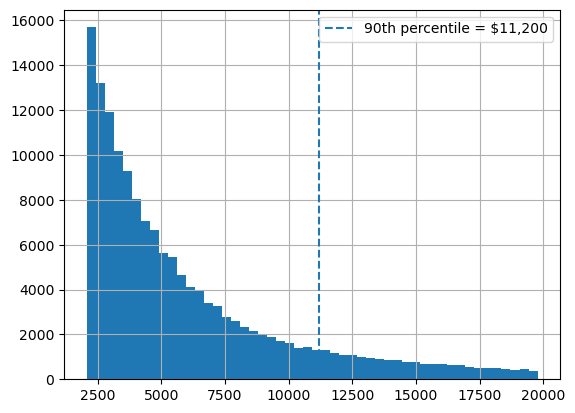

In [100]:
import matplotlib.pyplot as plt
patient["payer_care_cost"].hist(bins=50, range=(2070, 19774))
plt.axvline(
    payer_90,
    linestyle="--",
    label=f"90th percentile = ${payer_90:,.0f}"
)

plt.legend()

In [103]:
# Investigate the top OOP patients in the tail, because the maximum is 7.6x higher than the 99th percentile
(patient["out_of_pocket_care_cost"] > 10000).sum()

np.int64(573)

In [106]:
oop_components = [
    "total_carrier_beneficiary_cost",
    "total_inpatient_beneficiary_cost",
    "total_outpatient_beneficiary_cost",
    "total_medoop"
]
id_components =["DESYNPUF_ID", "year", "age"]
var_comp = id_components + oop_components
patient.nlargest(20, "out_of_pocket_care_cost")[var_comp]

,DESYNPUF_ID,year,age,total_carrier_beneficiary_cost,total_inpatient_beneficiary_cost,total_outpatient_beneficiary_cost,total_medoop
80420,B92999D0DB18CF1D,2008,64,1730.0,39164.0,1180.0,900.0
216512,F392CA53828B9E9A,2009,57,1200.0,38272.0,1240.0,190.0
130508,2D5FF7348653086F,2009,84,1260.0,37204.0,2030.0,20.0
166506,803EC72B029BD65B,2009,73,1410.0,36136.0,2450.0,180.0
203992,D67E1DA24035DF46,2009,83,730.0,37204.0,380.0,460.0
95583,DC50300BEEAAACB2,2008,93,1150.0,36048.0,1000.0,240.0
187501,B04ADA4EF3C1B8C8,2009,70,830.0,36136.0,450.0,480.0
139730,4253EF3B0F6A58BA,2009,80,1400.0,34136.0,1770.0,400.0
51007,75968A21066DE405,2008,86,890.0,36048.0,230.0,0.0
91687,D353F7E0522AA35E,2008,82,820.0,36048.0,150.0,70.0


Extreme beneficiary financial burden in this population was primarily associated with inpatient cost-sharing rather than prescription drug expenses.

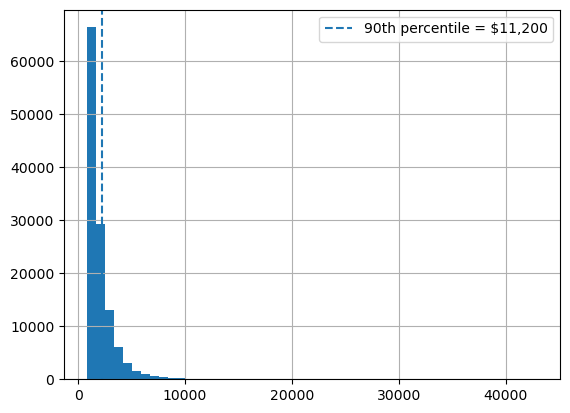

In [107]:
patient["out_of_pocket_care_cost"].hist(bins=50, range=(800, 42974))
plt.axvline(
    oop_90,
    linestyle="--",
    label=f"90th percentile = ${payer_90:,.0f}"
)

plt.legend()

After validating claim-derived payment measures, total financial impact was decomposed into payer care cost and out-of-pocket (OOP) care cost to capture distinct stakeholder perspectives.

Payer care cost demonstrated a typical healthcare expenditure distribution characterized by a right-skewed spending pattern, where a relatively small proportion of beneficiaries accounted for substantially higher healthcare utilization costs. 

Out-of-pocket care cost exhibited a different distribution pattern compared with payer spending. While most beneficiaries experienced relatively moderate direct financial burden, a small subset demonstrated substantially elevated OOP costs. The presence of a long upper tail suggests that extreme beneficiary financial burden is concentrated among a small subgroup. Inspection of high-OOP beneficiaries showed that these cases were primarily driven by inpatient beneficiary responsibility rather than prescription drug out-of-pocket spending.

Therefore, payer cost and OOP burden were analyzed separately rather than combined into a single cost outcome. This separation enables downstream identification of distinct high-risk populations, including:

* **High payer cost + low OOP burden**
(High healthcare utilization with limited direct financial exposure):
Potential opportunities for care coordination and utilization management
* **High payer cost + high OOP burden**
(High resource utilization combined with significant beneficiary financial burden):
Potential need for comprehensive intervention
* **Low payer cost + high OOP burden**
(Lower overall utilization but disproportionate beneficiary burden):
Potential indicator of coverage gaps or benefit design challenges

The high payer cost is defined as top 10% of payer care cost while high OOP burden is defined as top 10% of OOP care cost. Based on the distributions, we found the **high payer cost threshold is 11200.0** and **high out-of-pocket burden threshold is 2230.0**.

# **Part 3: ESRD Population Analysis**

In [108]:
patient["BENE_ESRD_IND"].value_counts()

BENE_ESRD_IND
0    306551
1     26143
Name: count, dtype: int64

In [109]:
patient.groupby("BENE_ESRD_IND")[[
        "payer_care_cost",
        "out_of_pocket_care_cost",
        "total_financial_impact"
    ]].describe()

payer_care_cost                                            \
                        count          mean           std   min     25%   
BENE_ESRD_IND                                                             
0                    306551.0   4033.713216   7367.913075   0.0   590.0   
1                     26143.0  13502.953754  17138.415815  10.0  3440.0   

                                         out_of_pocket_care_cost               \
                  50%      75%       max                   count         mean   
BENE_ESRD_IND                                                                   
0              1860.0   4400.0  190230.0                306551.0   785.431866   
1              7120.0  16280.0  197740.0                 26143.0  2357.498451   

                                                                 \
                       std  min    25%     50%     75%      max   
BENE_ESRD_IND                                                     
0              1042.934773  0.0  130.0   450.0  1090.0  40514.0   
1              2358.807719  0.0  860.0  1660.0  2998.0  42974.0   

              total_financial_impact                                    \
                               count          mean           std   min   
BENE_ESRD_IND                                                            
0                           306551.0   4819.145082   8155.720165   0.0   
1                            26143.0  15860.452205  19007.294919  10.0   

                                                  
                  25%     50%      75%       max  
BENE_ESRD_IND                                     
0               750.0  2360.0   5470.0  202136.0  
1              4380.0  8870.0  19439.0  213308.0

In [112]:
patient["high_payer_cost"] = (
    patient["payer_care_cost"] >= 
    patient["payer_care_cost"].quantile(0.9)
)

pd.crosstab(
    patient["high_payer_cost"],
    patient["BENE_ESRD_IND"],
    normalize="index"
)

BENE_ESRD_IND,0,1
high_payer_cost,,
False,0.943231,0.056769
True,0.725230,0.274770


Among low/normal cost patients, 94.3% are non-ESRD and 5.7% are ESRD. And among the high payer cost patients, 72.5% are non-ESRD and 27.5% are ESRD. This means ESRD beneficiaries (despite only being 7.86% of the patient-year record) are disproportionately represented among high payer-cost patients.

In [113]:
patient["high_oop_cost"] = (
    patient["out_of_pocket_care_cost"] >= 
    patient["out_of_pocket_care_cost"].quantile(0.9)
)

pd.crosstab(
    patient["high_oop_cost"],
    patient["BENE_ESRD_IND"],
    normalize="index"
)

BENE_ESRD_IND,0,1
high_oop_cost,,
False,0.945090,0.054910
True,0.709364,0.290636


Among low/normal oop burden patients, 94.5% are non-ESRD and 5.5% are ESRD. And among the high oop burden patients 70.9% are non-ESRD and 29.1% are ESRD. This also means ESRD beneficiaries are disproportionately facing heavier out-of-pocket burdens within their care.

In [115]:
esrd_summary = patient.groupby("BENE_ESRD_IND").agg(
    n_patients=("DESYNPUF_ID", "count"),
    avg_payer_cost=("payer_care_cost", "mean"),
    median_payer_cost=("payer_care_cost", "median"),
    avg_oop=("out_of_pocket_care_cost", "mean"),
    median_oop=("out_of_pocket_care_cost", "median"),
    avg_utilization=("num_service_types", "mean")
)

esrd_summary

,n_patients,avg_payer_cost,median_payer_cost,avg_oop,median_oop,avg_utilization
BENE_ESRD_IND,,,,,,
0,306551,4033.713216,1860.0,785.431866,450.0,2.094934
1,26143,13502.953754,7120.0,2357.498451,1660.0,3.018361


ESRD was retained as a patient-level feature because it represents a clinically meaningful chronic condition associated with substantially elevated healthcare utilization and spending. However, given that ESRD represents a distinct clinical subgroup rather than a generalizable characteristic of the overall population, ESRD beneficiaries were additionally analyzed as a separate subgroup to understand their contribution to high-cost utilization.

In [125]:
import shutil
patient.to_csv("patient_final.csv", index=False)
shutil.move("patient_final.csv", "cleaned_data")

'cleaned_data/patient_final.csv'